<a href="https://colab.research.google.com/github/San-Yamin/AI_Fraud_Adversarial/blob/main/notebooks/fraud_adversarial_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Fraud Detection and Adversarial Robustness

Complete Colab workflow for Phases 1–5. Phases 6–8 are provided through the Streamlit dashboard after the experiment artifacts are saved.

> Run cells in numerical order. Start in `DEVELOPMENT_MODE`; adversarial attack cells can take several minutes. The PaySim CSV and generated outputs remain in Google Drive.

## PHASE 1 — Fraud Detection

### Cell 1 — Environment / Imports

In [2]:
from pathlib import Path
import json
import os
import subprocess
import importlib.metadata
import signal
import sys

REPOSITORY_URL = 'https://github.com/San-Yamin/AI_Fraud_Adversarial.git'
COLAB_PROJECT_ROOT = Path('/content/AI_Fraud_Adversarial')
project_candidates = [Path.cwd(), COLAB_PROJECT_ROOT]
PROJECT_ROOT = next((p for p in project_candidates if (p / 'requirements-colab.txt').is_file()), None)
if PROJECT_ROOT is None:
    subprocess.run(['git', 'clone', REPOSITORY_URL, str(COLAB_PROJECT_ROOT)], check=True)
    PROJECT_ROOT = COLAB_PROJECT_ROOT
elif (PROJECT_ROOT / '.git').is_dir():
    subprocess.run(['git', 'pull', '--ff-only'], cwd=PROJECT_ROOT, check=True)
os.chdir(PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)
%pip install -q --upgrade -r requirements-colab.txt
loaded_numpy = sys.modules.get('numpy')
installed_numpy_version = importlib.metadata.version('numpy')
if loaded_numpy is not None and loaded_numpy.__version__ != installed_numpy_version:
    print(f'NumPy changed from {loaded_numpy.__version__} to {installed_numpy_version}. Restarting the Colab runtime once; rerun Cell 1 after reconnecting.', flush=True)
    os.kill(os.getpid(), signal.SIGTERM)
import joblib
import matplotlib.pyplot as plt
import pandas as pd


Project root: /content/AI_Fraud_Adversarial
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.5/386.5 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 119.8 MB/s eta 0:00:00


### Cell 2 — Google Drive Mount

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Cell 3 — Configuration

In [4]:
DATASET_PATH = Path('/content/drive/MyDrive/AI_Fraud_Adversarial/data/paysim.csv')
DEVELOPMENT_MODE = True  # Set False only for the final full-data run.
RUN_MODE = 'DEVELOPMENT_MODE' if DEVELOPMENT_MODE else 'FULL_MODE'
RANDOM_SEED = 42
OUTPUT_DIR = Path('/content/drive/MyDrive/AI_Fraud_Adversarial/outputs')
FIGURES_DIR = OUTPUT_DIR / 'figures' / 'phase1'
MODELS_DIR = OUTPUT_DIR / 'models'
METRICS_DIR = OUTPUT_DIR / 'metrics'
for directory in (FIGURES_DIR, MODELS_DIR, METRICS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print({'run_mode': RUN_MODE, 'dataset': str(DATASET_PATH), 'outputs': str(OUTPUT_DIR)})

{'run_mode': 'DEVELOPMENT_MODE', 'dataset': '/content/drive/MyDrive/AI_Fraud_Adversarial/data/paysim.csv', 'outputs': '/content/drive/MyDrive/AI_Fraud_Adversarial/outputs'}


### Cell 4 — Dataset Check

In [5]:
if not DATASET_PATH.is_file():
    raise FileNotFoundError(f'PaySim CSV not found: {DATASET_PATH}')
print(f'PaySim found: {DATASET_PATH} ({DATASET_PATH.stat().st_size / 1e9:.2f} GB)')

PaySim found: /content/drive/MyDrive/AI_Fraud_Adversarial/data/paysim.csv (0.49 GB)


### Cell 5 — Load PaySim

In [7]:
from src.data_loader import load_paysim
data = load_paysim(DATASET_PATH, run_mode=RUN_MODE, random_seed=RANDOM_SEED)
print(f'Loaded {len(data):,} rows in {RUN_MODE}.')

Loaded 52,000 rows in DEVELOPMENT_MODE.


### Cell 6 — Inspect Dataset

In [8]:
from src.data_loader import summarize_paysim
summary = summarize_paysim(data)
print('Shape:', summary['shape'])
print('Columns:', summary['columns'])
print('Missing values:', summary['missing_values'])
print('Transaction types:', summary['transaction_types'])
print('Class counts:', summary['class_counts'])
print(f"Fraud percentage: {summary['fraud_percentage']:.6f}%")

Shape: (52000, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Missing values: {'step': 0, 'type': 0, 'amount': 0, 'nameOrig': 0, 'oldbalanceOrg': 0, 'newbalanceOrig': 0, 'nameDest': 0, 'oldbalanceDest': 0, 'newbalanceDest': 0, 'isFraud': 0, 'isFlaggedFraud': 0}
Transaction types: {'CASH_OUT': 18622, 'PAYMENT': 17005, 'CASH_IN': 10872, 'TRANSFER': 5187, 'DEBIT': 314}
Class counts: {'legitimate': 50000, 'fraud': 2000}
Fraud percentage: 3.846154%


### Cell 7 — Preprocess and Engineer Features

In [9]:
from src.preprocessing import prepare_features_and_target
X, y = prepare_features_and_target(data)
print('Raw model inputs:', X.columns.tolist())
print('Target counts:', y.value_counts().sort_index().to_dict())

Raw model inputs: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'sender_balance_change', 'receiver_balance_change', 'amount_to_sender_balance']
Target counts: {0: 50000, 1: 2000}


### Cell 8 — Train/Test Split

In [10]:
from src.preprocessing import fit_transform_train_test
from src.train import stratified_train_test_split
X_train_raw, X_test_raw, y_train, y_test = stratified_train_test_split(
    X, y, random_state=RANDOM_SEED
)
X_train, X_test, preprocessor = fit_transform_train_test(X_train_raw, X_test_raw)
feature_names = X_train.columns.tolist()
print('Training counts:', y_train.value_counts().sort_index().to_dict())
print('Untouched test counts:', y_test.value_counts().sort_index().to_dict())
print('Encoded features:', feature_names)

Training counts: {0: 40000, 1: 1600}
Untouched test counts: {0: 10000, 1: 400}
Encoded features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'sender_balance_change', 'receiver_balance_change', 'amount_to_sender_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


### Cell 9 — SMOTE

In [11]:
from src.config import SMOTE_SAMPLING_STRATEGY
from src.preprocessing import resample_training_data
print('Before SMOTE:', y_train.value_counts().sort_index().to_dict())
X_train_smote, y_train_smote = resample_training_data(
    X_train, y_train, random_state=RANDOM_SEED,
    sampling_strategy=SMOTE_SAMPLING_STRATEGY
)
print('After SMOTE:', pd.Series(y_train_smote).value_counts().sort_index().to_dict())
print('Test data was not passed to SMOTE.')

Before SMOTE: {0: 40000, 1: 1600}
After SMOTE: {0: 40000, 1: 4000}
Test data was not passed to SMOTE.


### Cell 10 — Train Baseline Model

In [12]:
from src.train import train_baseline_model
baseline_model = train_baseline_model(X_train_smote, y_train_smote)
print('Baseline XGBoost training complete.')

Baseline XGBoost training complete.


### Cell 11 — Evaluate Baseline

{
  "precision": 0.9925,
  "recall": 0.9925,
  "f1_score": 0.9925,
  "pr_auc": 0.9969595943721075,
  "accuracy_supplementary": 0.999423076923077
}
Fraud Recall (primary concern): 0.9925
              precision    recall  f1-score       support
0              0.999700  0.999700  0.999700  10000.000000
1              0.992500  0.992500  0.992500    400.000000
accuracy       0.999423  0.999423  0.999423      0.999423
macro avg      0.996100  0.996100  0.996100  10400.000000
weighted avg   0.999423  0.999423  0.999423  10400.000000


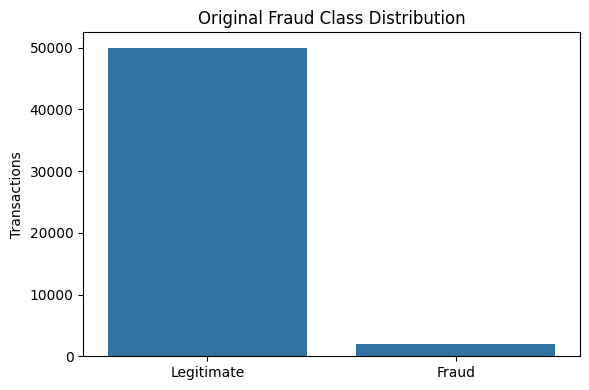

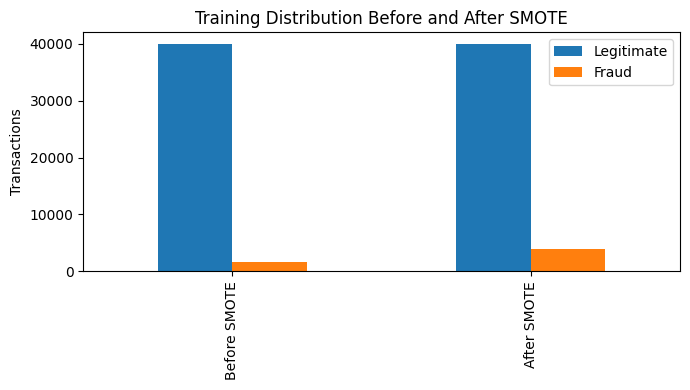

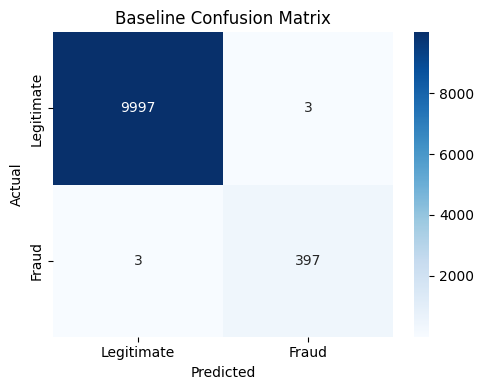

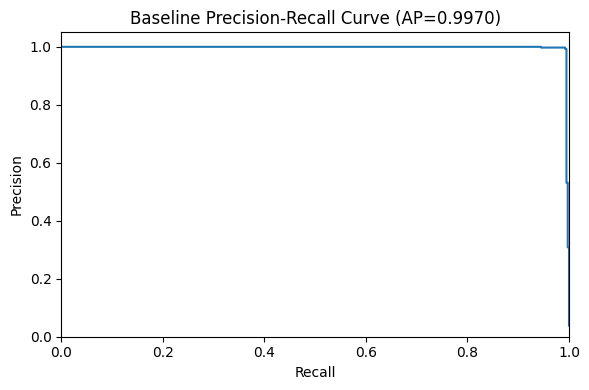

In [13]:
from src.evaluate import evaluate_binary_classifier
from src.visualization import (
    plot_confusion_matrix, plot_original_class_distribution,
    plot_precision_recall, plot_smote_distributions,
)
evaluation = evaluate_binary_classifier(baseline_model, X_test, y_test)
print(json.dumps(evaluation['metrics'], indent=2))
print('Fraud Recall (primary concern):', evaluation['metrics']['recall'])
print(pd.DataFrame(evaluation['classification_report']).transpose())
plot_original_class_distribution(y, FIGURES_DIR)
plot_smote_distributions(y_train, y_train_smote, FIGURES_DIR)
plot_confusion_matrix(evaluation['confusion_matrix'], FIGURES_DIR)
plot_precision_recall(evaluation, FIGURES_DIR)
plt.show()

### Cell 12 — Save Artifacts

In [14]:
from src.evaluate import save_metrics
baseline_model_path = MODELS_DIR / 'baseline_model.joblib'
feature_names_path = MODELS_DIR / 'feature_names.joblib'
preprocessor_path = MODELS_DIR / 'baseline_preprocessor.joblib'
metrics_path = METRICS_DIR / 'phase1_baseline_metrics.json'
joblib.dump(baseline_model, baseline_model_path)
joblib.dump(feature_names, feature_names_path)
joblib.dump(preprocessor, preprocessor_path)
save_metrics(evaluation, metrics_path)
print('Saved:', baseline_model_path, feature_names_path, preprocessor_path, metrics_path, sep='\n- ')

Saved:
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/models/baseline_model.joblib
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/models/feature_names.joblib
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/models/baseline_preprocessor.joblib
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase1_baseline_metrics.json


# PHASE 2 — SHAP Explainability
Reuse the trained Phase 1 baseline. Do not retrain it.

### Cell 13 — Load Phase 1 Artifacts

In [13]:
from src.explainability import load_phase1_artifacts
baseline_model, saved_preprocessor, saved_feature_names = load_phase1_artifacts(
    MODELS_DIR / 'baseline_model.joblib',
    MODELS_DIR / 'baseline_preprocessor.joblib',
    MODELS_DIR / 'feature_names.joblib',
)
print(f'Loaded baseline model with {len(saved_feature_names)} encoded features.')
print('The baseline model was loaded, not retrained.')

Loaded baseline model with 14 encoded features.
The baseline model was loaded, not retrained.


### Cell 14 — Prepare SHAP Evaluation Sample

In [14]:
from src.explainability import prepare_shap_evaluation_sample, transform_with_saved_preprocessor
# Reuse the live Phase 1 test split. Reconstruct it deterministically after a restart.
if 'X_test' not in globals() or 'y_test' not in globals():
    from src.data_loader import load_paysim
    from src.preprocessing import prepare_features_and_target
    from src.train import stratified_train_test_split
    reconstructed_data = load_paysim(DATASET_PATH, run_mode=RUN_MODE, random_seed=RANDOM_SEED)
    reconstructed_X, reconstructed_y = prepare_features_and_target(reconstructed_data)
    _, X_test_raw, _, y_test = stratified_train_test_split(
        reconstructed_X, reconstructed_y, random_state=RANDOM_SEED
    )
    X_test = transform_with_saved_preprocessor(
        saved_preprocessor, X_test_raw, saved_feature_names
    )
else:
    if X_test.columns.tolist() != saved_feature_names:
        raise ValueError('Live test features do not match saved Phase 1 feature names.')
X_shap, y_shap = prepare_shap_evaluation_sample(
    X_test, y_test, random_state=RANDOM_SEED
)
print('SHAP sample shape:', X_shap.shape)
print('SHAP sample labels:', y_shap.value_counts().sort_index().to_dict())
print('This class-aware held-out sample is for explanation, not prevalence estimation.')

SHAP sample shape: (1000, 14)
SHAP sample labels: {0: 750, 1: 250}
This class-aware held-out sample is for explanation, not prevalence estimation.


### Cell 15 — Create SHAP Explainer

In [7]:
from src.explainability import create_tree_explainer, compute_shap_values
shap_explainer = create_tree_explainer(baseline_model)
shap_values = compute_shap_values(shap_explainer, X_shap)
print('Computed Tree SHAP values:', shap_values.values.shape)
print('Positive SHAP values push the raw model margin toward fraud; negative values push toward legitimate.')

Computed Tree SHAP values: (1000, 14)
Positive SHAP values push the raw model margin toward fraud; negative values push toward legitimate.


### Cell 16 — Global SHAP Feature Importance

,feature,mean_absolute_shap,mean_signed_shap
0,sender_balance_change,3.047551,-1.126178
1,amount_to_sender_balance,2.565956,-0.028113
2,newbalanceOrig,1.223233,-0.505986
3,type_CASH_OUT,0.745137,-0.367749
4,step,0.629232,-0.332517
5,type_TRANSFER,0.583237,-0.131582
6,oldbalanceDest,0.576823,-0.061275
7,amount,0.490560,-0.177496
8,receiver_balance_change,0.460469,0.124184
9,type_PAYMENT,0.384312,-0.155687


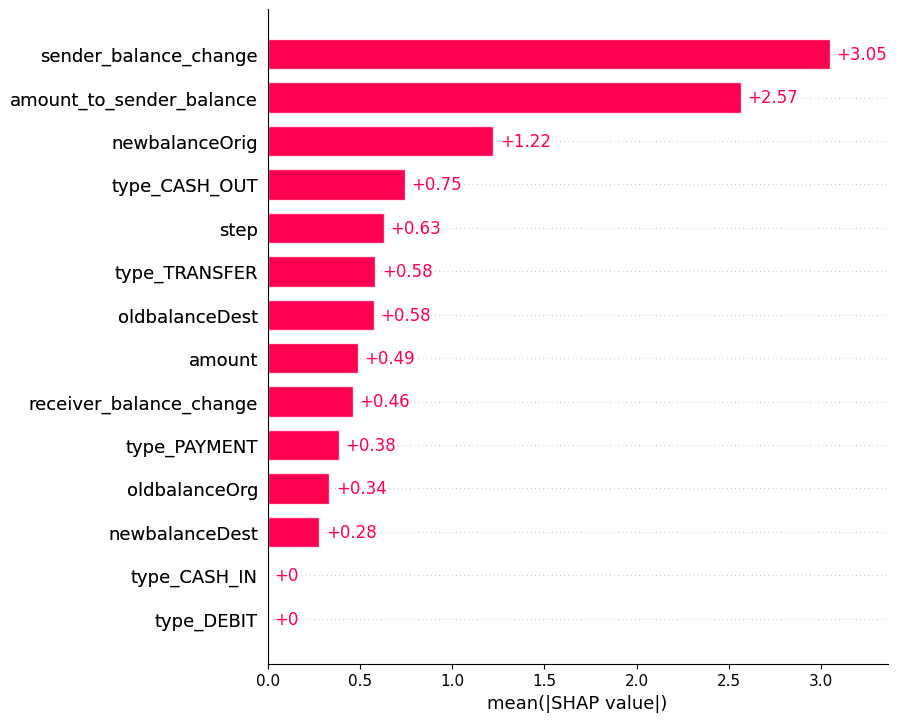

In [8]:
from src.explainability import rank_global_importance
global_importance = rank_global_importance(shap_values)
display(global_importance)
import shap
shap.plots.bar(shap_values, max_display=15)

### Cell 17 — SHAP Summary Plot

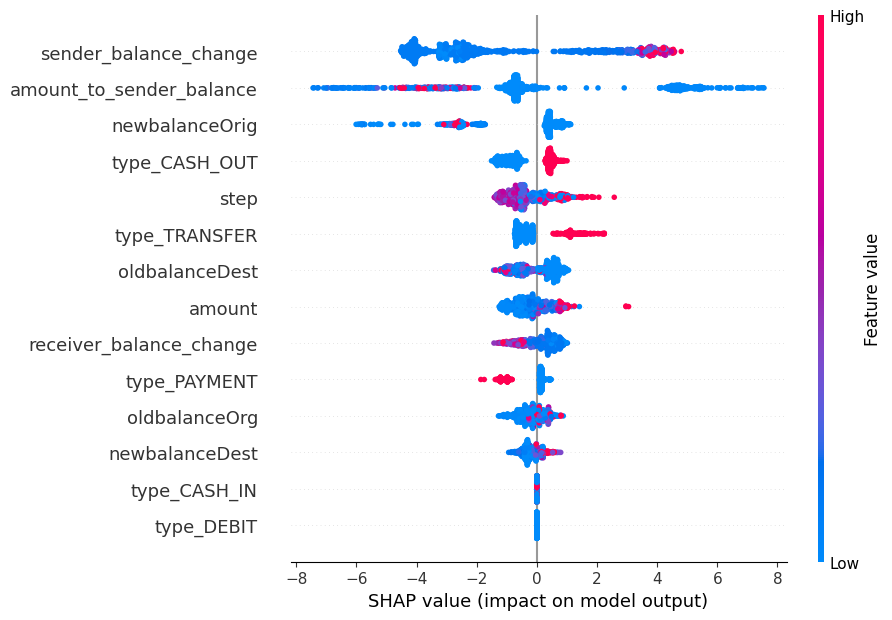

In [9]:
shap.plots.beeswarm(shap_values, max_display=15)

### Cell 18 — Explain Correctly Detected Fraud

{
  "position": 807,
  "index": "35317",
  "actual_label": 1,
  "predicted_label": 1,
  "fraud_probability": 0.9999265670776367,
  "top_features_toward_fraud": [
    {
      "feature": "amount_to_sender_balance",
      "feature_value": 1.0,
      "shap_value": 5.305161952972412
    },
    {
      "feature": "sender_balance_change",
      "feature_value": 348751.4375,
      "shap_value": 3.805647850036621
    },
    {
      "feature": "newbalanceOrig",
      "feature_value": 0.0,
      "shap_value": 0.8236913084983826
    },
    {
      "feature": "oldbalanceDest",
      "feature_value": 698.2899780273438,
      "shap_value": 0.8136512041091919
    },
    {
      "feature": "step",
      "feature_value": 621.0,
      "shap_value": 0.7817762494087219
    }
  ],
  "top_features_toward_legitimate": [
    {
      "feature": "receiver_balance_change",
      "feature_value": 348751.46875,
      "shap_value": -0.42819154262542725
    },
    {
      "feature": "newbalanceDest",
      "feature_v

,feature,feature_value,shap_value,direction
0,amount_to_sender_balance,1.000000,5.305162,toward fraud
1,sender_balance_change,348751.437500,3.805648,toward fraud
2,newbalanceOrig,0.000000,0.823691,toward fraud
3,oldbalanceDest,698.289978,0.813651,toward fraud
4,step,621.000000,0.781776,toward fraud
5,amount,348751.437500,0.574878,toward fraud
6,type_CASH_OUT,1.000000,0.471159,toward fraud
7,receiver_balance_change,348751.468750,-0.428192,toward legitimate
8,newbalanceDest,349449.750000,-0.170579,toward legitimate
9,type_PAYMENT,0.000000,0.165570,toward fraud


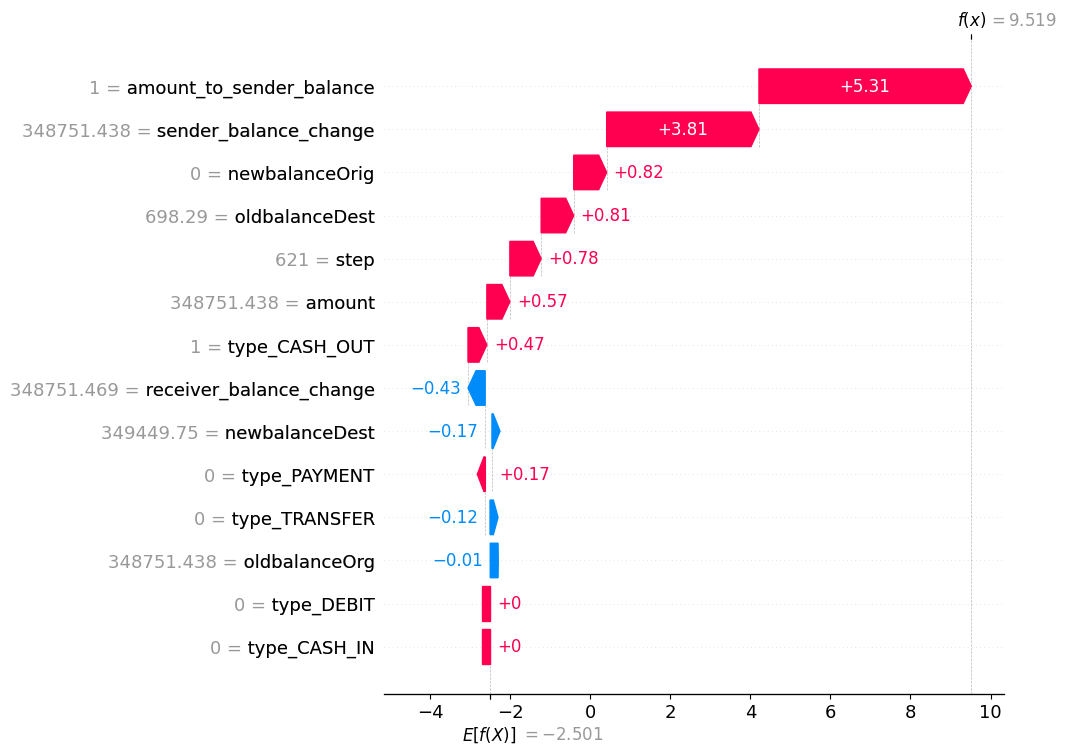

In [10]:
from src.explainability import build_interpretation, explain_selected_row, select_correct_examples
selected_examples = select_correct_examples(
    baseline_model, X_test, y_test, random_state=RANDOM_SEED
)
fraud_explanation, fraud_table = explain_selected_row(
    shap_explainer, X_test, selected_examples['fraud']
)
fraud_interpretation = build_interpretation(
    selected_examples['fraud'], fraud_table
)
print(json.dumps(fraud_interpretation, indent=2, default=str))
display(fraud_table.head(15))
shap.plots.waterfall(fraud_explanation, max_display=15)

### Cell 19 — Explain Correctly Detected Legitimate Transaction

{
  "position": 8052,
  "index": "50888",
  "actual_label": 0,
  "predicted_label": 0,
  "fraud_probability": 0.0025065301451832056,
  "top_features_toward_fraud": [
    {
      "feature": "sender_balance_change",
      "feature_value": 63148.0,
      "shap_value": 2.187697172164917
    },
    {
      "feature": "newbalanceDest",
      "feature_value": 8931432.0,
      "shap_value": 0.6892874240875244
    },
    {
      "feature": "oldbalanceDest",
      "feature_value": 8776679.0,
      "shap_value": 0.6470911502838135
    },
    {
      "feature": "newbalanceOrig",
      "feature_value": 0.0,
      "shap_value": 0.4734435975551605
    },
    {
      "feature": "type_CASH_OUT",
      "feature_value": 1.0,
      "shap_value": 0.35748234391212463
    }
  ],
  "top_features_toward_legitimate": [
    {
      "feature": "amount_to_sender_balance",
      "feature_value": 2.4506466388702393,
      "shap_value": -5.265259742736816
    },
    {
      "feature": "step",
      "feature_value": 3

,feature,feature_value,shap_value,direction
0,amount_to_sender_balance,2.450647e+00,-5.265260,toward legitimate
1,sender_balance_change,6.314800e+04,2.187697,toward fraud
2,step,3.950000e+02,-1.222211,toward legitimate
3,newbalanceDest,8.931432e+06,0.689287,toward fraud
4,amount,1.547534e+05,-0.652389,toward legitimate
5,oldbalanceDest,8.776679e+06,0.647091,toward fraud
6,newbalanceOrig,0.000000e+00,0.473444,toward fraud
7,type_CASH_OUT,1.000000e+00,0.357482,toward fraud
8,oldbalanceOrg,6.314800e+04,-0.348328,toward legitimate
9,type_TRANSFER,0.000000e+00,-0.237453,toward legitimate


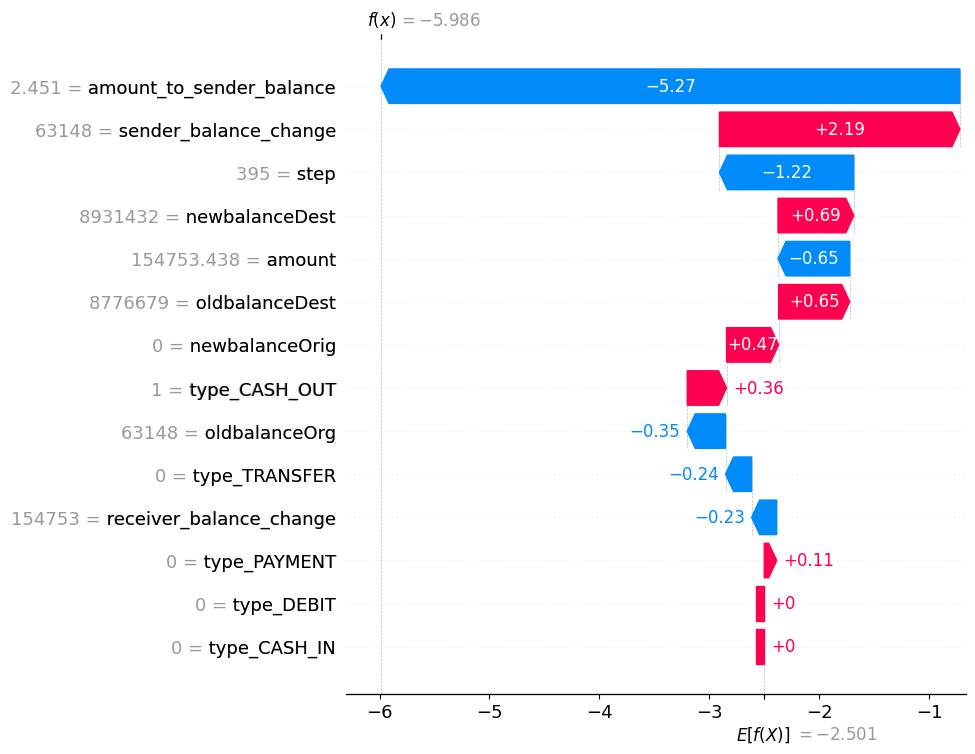

In [11]:
legitimate_explanation, legitimate_table = explain_selected_row(
    shap_explainer, X_test, selected_examples['legitimate']
)
legitimate_interpretation = build_interpretation(
    selected_examples['legitimate'], legitimate_table
)
print(json.dumps(legitimate_interpretation, indent=2, default=str))
display(legitimate_table.head(15))
shap.plots.waterfall(legitimate_explanation, max_display=15)

### Cell 20 — Save SHAP Outputs and Interpretation

In [12]:
from src.explainability import save_global_plots, save_phase2_outputs, save_waterfall_plot
SHAP_OUTPUT_DIR = OUTPUT_DIR / 'shap'
save_global_plots(shap_values, SHAP_OUTPUT_DIR, max_display=15)
save_waterfall_plot(
    fraud_explanation, SHAP_OUTPUT_DIR / 'correct_fraud_waterfall.png', max_display=15
)
save_waterfall_plot(
    legitimate_explanation, SHAP_OUTPUT_DIR / 'correct_legitimate_waterfall.png', max_display=15
)
saved_shap_paths = save_phase2_outputs(
    SHAP_OUTPUT_DIR,
    global_importance,
    {'fraud': fraud_table, 'legitimate': legitimate_table},
    {'fraud': fraud_interpretation, 'legitimate': legitimate_interpretation},
    y_shap,
)
print('Saved Phase 2 outputs:')
for path in sorted(SHAP_OUTPUT_DIR.iterdir()):
    print('-', path)

Saved Phase 2 outputs:
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/correct_fraud_waterfall.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/correct_legitimate_waterfall.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/global_feature_importance.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/global_feature_importance_bar.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/global_summary_beeswarm.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/local_fraud_explanation.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/local_legitimate_explanation.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/shap/phase2_interpretation.json


# PHASE 3 — Adversarial Evasion Attack
Targeted, decision-based HopSkipJump on correctly detected held-out fraud only. Generated test samples are evaluation-only and must never be used for training.

### Cell 21 — ART Setup and Compatibility Check

In [15]:
import importlib.util
import subprocess
import sys
if importlib.util.find_spec('art') is None:
    print('ART is missing; installing adversarial-robustness-toolbox from requirements-colab.txt...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements-colab.txt'])
import art
from art.attacks.evasion import HopSkipJump
from art.estimators.classification import BlackBoxClassifier, XGBoostClassifier
from src.attack import verify_art_compatibility
art_compatibility = verify_art_compatibility(baseline_model, saved_feature_names)
print(json.dumps(art_compatibility, indent=2))
print('Available ART wrappers:', BlackBoxClassifier.__name__, XGBoostClassifier.__name__)
print('Selected attack:', HopSkipJump.__name__)
print('Reason: HSJ needs predictions/decisions, not gradients, and the black-box adapter enforces valid feature dependencies.')

{
  "art_version": "1.20.1",
  "model_type": "xgboost.sklearn.XGBClassifier",
  "model_feature_count": 14,
  "art_estimator": "BlackBoxClassifier",
  "attack": "HopSkipJump",
  "attack_type": "targeted decision-based black-box",
  "estimator_requirements": [
    "BaseEstimator",
    "ClassifierMixin"
  ],
  "compatible": true
}
Available ART wrappers: BlackBoxClassifier XGBoostClassifier
Selected attack: HopSkipJump
Reason: HSJ needs predictions/decisions, not gradients, and the black-box adapter enforces valid feature dependencies.


### Cell 22 — Build Feature Threat Model

In [16]:
from src.attack import build_feature_threat_model
from src.config import ATTACK_RELATIVE_BOUND
feature_threat_model = build_feature_threat_model(
    X_test, relative_bound=ATTACK_RELATIVE_BOUND
)
display(feature_threat_model)
print('Direct monetary changes are bounded and non-negative.')
print('Engineered values are recomputed; step and one-hot transaction type are protected.')

,feature_name,mutable,attack_handling,valid_range,reason,dependencies
0,step,False,protected,"fixed clean value; observed [1, 741]",Transaction time/context is outside the attack...,none
1,amount,True,directly attacked,"per-row [max(0, clean×0.90), clean×1.10]",Bounded non-negative monetary value,amount_to_sender_balance
2,oldbalanceOrg,True,directly attacked,"per-row [max(0, clean×0.90), clean×1.10]",Bounded non-negative monetary value,"sender_balance_change, amount_to_sender_balance"
3,newbalanceOrig,True,directly attacked,"per-row [max(0, clean×0.90), clean×1.10]",Bounded non-negative monetary value,sender_balance_change
4,oldbalanceDest,True,directly attacked,"per-row [max(0, clean×0.90), clean×1.10]",Bounded non-negative monetary value,receiver_balance_change
5,newbalanceDest,True,directly attacked,"per-row [max(0, clean×0.90), clean×1.10]",Bounded non-negative monetary value,receiver_balance_change
6,sender_balance_change,True,recomputed only,deterministically derived from bounded raw mon...,Cannot be attacked independently; relationship...,oldbalanceOrg - newbalanceOrig
7,receiver_balance_change,True,recomputed only,deterministically derived from bounded raw mon...,Cannot be attacked independently; relationship...,newbalanceDest - oldbalanceDest
8,amount_to_sender_balance,True,recomputed only,deterministically derived from bounded raw mon...,Cannot be attacked independently; relationship...,amount / oldbalanceOrg; 0 when denominator is 0
9,type_CASH_IN,False,protected,"fixed clean one-hot value in {0, 1}",Protects categorical validity; no invalid/frac...,entire transaction-type one-hot group


Direct monetary changes are bounded and non-negative.
Engineered values are recomputed; step and one-hot transaction type are protected.


### Cell 23 — Select Correctly Detected Fraud Test Samples

In [17]:
from src.attack import select_correctly_detected_test_fraud
from src.config import ATTACK_SAMPLE_SIZE
X_attack_clean, y_attack, attack_population = select_correctly_detected_test_fraud(
    baseline_model, X_test, y_test, sample_size=ATTACK_SAMPLE_SIZE,
    random_state=RANDOM_SEED,
)
print(json.dumps(attack_population, indent=2))
print('Selected source test indices:', X_attack_clean.index.tolist())
assert y_attack.eq(1).all()
assert (baseline_model.predict(X_attack_clean) == 1).all()

{
  "total_test_fraud": 400,
  "correctly_detected_test_fraud": 397,
  "full_test_clean_fraud_recall": 0.9925,
  "selected_attacked_samples": 20
}
Selected source test indices: [17961, 27055, 21991, 30244, 4992, 26083, 4458, 16052, 23988, 43020, 44636, 4315, 12535, 3822, 18758, 11521, 2718, 16944, 3897, 24756]


### Cell 24 — Configure Adversarial Attack

In [18]:
from src.config import (ATTACK_INIT_EVAL, ATTACK_INIT_SIZE, ATTACK_MAX_EVAL, ATTACK_MAX_ITER)
attack_configuration = {
    'attack': 'Targeted HopSkipJump',
    'target_class': 0,
    'relative_monetary_bound': ATTACK_RELATIVE_BOUND,
    'max_iter': ATTACK_MAX_ITER,
    'max_eval': ATTACK_MAX_EVAL,
    'init_eval': ATTACK_INIT_EVAL,
    'init_size': ATTACK_INIT_SIZE,
    'random_seed': RANDOM_SEED,
    'evaluation_only': True,
}
print(json.dumps(attack_configuration, indent=2))

{
  "attack": "Targeted HopSkipJump",
  "target_class": 0,
  "relative_monetary_bound": 0.1,
  "max_iter": 10,
  "max_eval": 500,
  "init_eval": 50,
  "init_size": 30,
  "random_seed": 42,
  "evaluation_only": true
}


### Cell 25 — Generate Adversarial TEST Samples

In [19]:
from src.attack import generate_constrained_hopskipjump
X_attack_adversarial, attack_execution = generate_constrained_hopskipjump(
    baseline_model, X_attack_clean,
    relative_bound=ATTACK_RELATIVE_BOUND,
    max_iter=ATTACK_MAX_ITER, max_eval=ATTACK_MAX_EVAL,
    init_eval=ATTACK_INIT_EVAL, init_size=ATTACK_INIT_SIZE,
    random_state=RANDOM_SEED, verbose=True,
)
print(json.dumps(attack_execution, indent=2))
print('Generated adversarial test matrix:', X_attack_adversarial.shape)
print('Original X_test remains unchanged; adversarial rows are stored separately.')

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

...

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "art_version": "1.20.1",
  "model_type": "xgboost.sklearn.XGBClassifier",
  "model_feature_count": 14,
  "art_estimator": "BlackBoxClassifier",
  "attack": "HopSkipJump",
  "attack_type": "targeted decision-based black-box",
  "estimator_requirements": [
    "BaseEstimator",
    "ClassifierMixin"
  ],
  "compatible": true,
  "runtime_seconds": 8.78395215799992,
  "total_model_queries": 24483,
  "queries_per_sample": [
    1224,
    1223,
    1223,
    1227,
    1223,
    1226,
    1225,
    1225,
    1226,
    1223,
    1227,
    1223,
    1224,
    1224,
    1223,
    1223,
    1223,
    1223,
    1223,
    1225
  ],
  "relative_bound": 0.1,
  "random_seed": 42,
  "attack_parameters": {
    "target_class": 0,
    "norm": 2,
    "max_iter": 10,
    "max_eval": 500,
    "init_eval": 50,
    "init_size": 30
  }
}
Generated adversarial test matrix: (20, 14)
Original X_test remains unchanged; adversarial rows are stored separately.


### Cell 26 — Evaluate Recall Under Attack

In [20]:
from src.evaluate import evaluate_adversarial_evasion
phase3_metrics, attacked_samples = evaluate_adversarial_evasion(
    baseline_model, X_attack_clean, X_attack_adversarial,
    full_test_clean_fraud_recall=attack_population['full_test_clean_fraud_recall'],
    attack_metadata=attack_execution,
)
print('Full-test clean fraud recall:', phase3_metrics['full_test_clean_fraud_recall'])
print('Selected-sample clean recall:', phase3_metrics['attacked_sample_clean_recall'])
print('Recall under attack:', phase3_metrics['recall_under_attack'])
print('Recall drop:', phase3_metrics['recall_drop_on_attacked_sample'])

Full-test clean fraud recall: 0.9925
Selected-sample clean recall: 1.0
Recall under attack: 0.0
Recall drop: 1.0


### Cell 27 — Calculate Attack Success Rate

Attack success definition: successful fraud-to-legitimate evasions divided by originally correctly detected attacked test fraud
Successful evasions: 20
Number attacked: 20
Attack success/evasion rate: 1.0
Average L2 perturbation: 3114.617782343993
Maximum L2 perturbation: 20939.887368369655


,source_test_index,actual_label,clean_prediction,adversarial_prediction,clean_fraud_probability,adversarial_fraud_probability,successful_evasion,l2_perturbation,linf_perturbation,clean_step,...,clean_type_CASH_IN,adversarial_type_CASH_IN,clean_type_CASH_OUT,adversarial_type_CASH_OUT,clean_type_DEBIT,adversarial_type_DEBIT,clean_type_PAYMENT,adversarial_type_PAYMENT,clean_type_TRANSFER,adversarial_type_TRANSFER
0,17961,1,1,0,0.999868,0.015778,True,3796.141077,2193.250000,370.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,27055,1,1,0,0.999891,0.019018,True,4254.021568,2516.250000,401.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,21991,1,1,0,0.999920,0.269909,True,896.479792,544.093750,120.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,30244,1,1,0,0.999944,0.373098,True,20939.887368,12427.000000,694.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,4992,1,1,0,0.998773,0.047027,True,9.563722,5.616211,85.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5,26083,1,1,0,0.999938,0.324657,True,1195.609158,720.000000,431.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,4458,1,1,0,0.999915,0.274550,True,1336.717084,773.500000,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
7,16052,1,1,0,0.999492,0.045674,True,17454.081722,10398.500000,348.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,23988,1,1,0,0.998767,0.003134,True,205.740452,121.960938,640.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,43020,1,1,0,0.999938,0.324657,True,1138.435522,703.656250,528.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


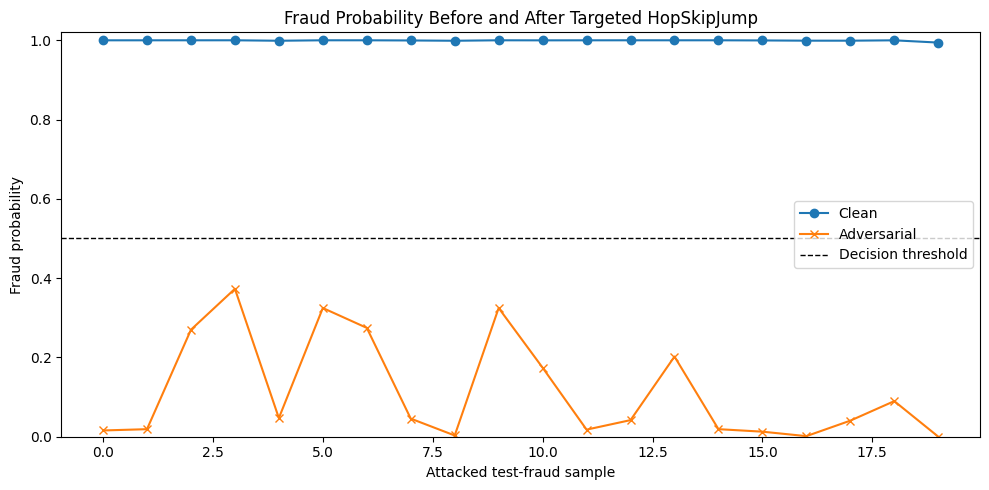

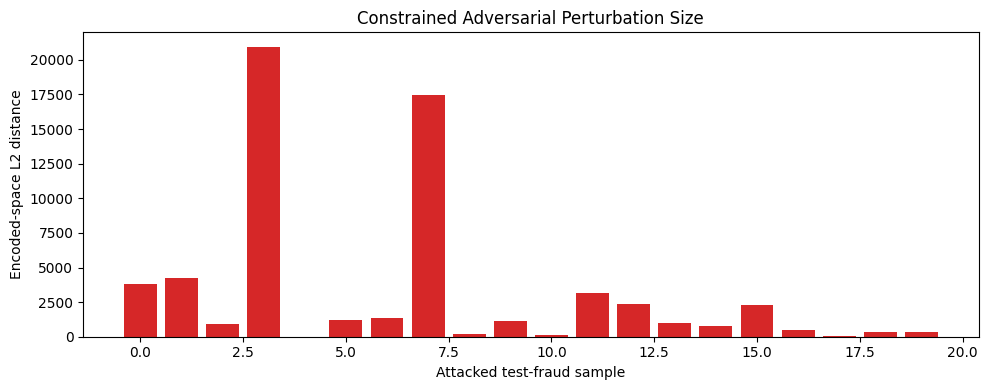

In [21]:
from src.visualization import plot_attack_perturbations, plot_attack_probabilities
PHASE3_FIGURES_DIR = OUTPUT_DIR / 'figures' / 'phase3'
print('Attack success definition:', phase3_metrics['attack_success_definition'])
print('Successful evasions:', phase3_metrics['successful_evasions'])
print('Number attacked:', phase3_metrics['number_attacked'])
print('Attack success/evasion rate:', phase3_metrics['attack_success_rate'])
print('Average L2 perturbation:', phase3_metrics['average_l2_perturbation'])
print('Maximum L2 perturbation:', phase3_metrics['max_l2_perturbation'])
display(attacked_samples)
plot_attack_probabilities(attacked_samples, PHASE3_FIGURES_DIR)
plot_attack_perturbations(attacked_samples, PHASE3_FIGURES_DIR)
plt.show()

### Cell 28 — Save Phase 3 Attack Outputs

In [22]:
from src.evaluate import save_attack_outputs
phase3_metrics_path = METRICS_DIR / 'phase3_attack_metrics.json'
phase3_samples_path = METRICS_DIR / 'phase3_attacked_samples.csv'
phase3_threat_model_path = METRICS_DIR / 'phase3_feature_constraints.csv'
save_attack_outputs(
    phase3_metrics, attacked_samples, phase3_metrics_path, phase3_samples_path
)
feature_threat_model.to_csv(phase3_threat_model_path, index=False)
print('Saved Phase 3 outputs:')
for path in (phase3_metrics_path, phase3_samples_path, phase3_threat_model_path):
    print('-', path)
for path in sorted(PHASE3_FIGURES_DIR.iterdir()):
    print('-', path)
print('Evaluation-only adversarial test samples were not saved as training data.')

Saved Phase 3 outputs:
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase3_attack_metrics.json
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase3_attacked_samples.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase3_feature_constraints.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase3/attack_fraud_probabilities.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase3/attack_perturbation_sizes.png
Evaluation-only adversarial test samples were not saved as training data.


# PHASE 4 — Multiple Attack Comparison
Compare three compatible ART attacks on the same constrained, evaluation-only held-out fraud population. Do not train on these samples.

### Cell 29 — Phase 4 Setup

In [23]:
from src import config as project_config
print('Phase 4 config loaded from:', project_config.__file__)
ATTACK_INIT_EVAL = getattr(project_config, 'ATTACK_INIT_EVAL', 50)
ATTACK_INIT_SIZE = getattr(project_config, 'ATTACK_INIT_SIZE', 30)
ATTACK_MAX_EVAL = getattr(project_config, 'ATTACK_MAX_EVAL', 500)
ATTACK_MAX_ITER = getattr(project_config, 'ATTACK_MAX_ITER', 10)
ATTACK_RELATIVE_BOUND = getattr(project_config, 'ATTACK_RELATIVE_BOUND', 0.10)
PHASE4_ATTACK_SAMPLE_SIZE = getattr(
    project_config, 'PHASE4_ATTACK_SAMPLE_SIZE',
    getattr(project_config, 'ATTACK_SAMPLE_SIZE', 20),
)
BOUNDARY_MAX_ITER = getattr(project_config, 'BOUNDARY_MAX_ITER', 50)
BOUNDARY_NUM_TRIAL = getattr(project_config, 'BOUNDARY_NUM_TRIAL', 10)
BOUNDARY_SAMPLE_SIZE = getattr(project_config, 'BOUNDARY_SAMPLE_SIZE', 10)
ZOO_MAX_ITER = getattr(project_config, 'ZOO_MAX_ITER', 20)
ZOO_LEARNING_RATE = getattr(project_config, 'ZOO_LEARNING_RATE', 0.05)
ZOO_NB_PARALLEL = getattr(project_config, 'ZOO_NB_PARALLEL', 5)
phase4_attack_parameters = {
    'HopSkipJump': {
        'max_iter': ATTACK_MAX_ITER, 'max_eval': ATTACK_MAX_EVAL,
        'init_eval': ATTACK_INIT_EVAL, 'init_size': ATTACK_INIT_SIZE,
    },
    'BoundaryAttack': {
        'max_iter': BOUNDARY_MAX_ITER, 'num_trial': BOUNDARY_NUM_TRIAL,
        'sample_size': BOUNDARY_SAMPLE_SIZE, 'init_size': ATTACK_INIT_SIZE,
    },
    'ZooAttack': {
        'max_iter': ZOO_MAX_ITER, 'learning_rate': ZOO_LEARNING_RATE,
        'nb_parallel': ZOO_NB_PARALLEL,
    },
}
phase4_results = {}
phase4_sample_results = {}
print(json.dumps(phase4_attack_parameters, indent=2))

Phase 4 config loaded from: /content/AI_Fraud_Adversarial/src/config.py
{
  "HopSkipJump": {
    "max_iter": 10,
    "max_eval": 500,
    "init_eval": 50,
    "init_size": 30
  },
  "BoundaryAttack": {
    "max_iter": 50,
    "num_trial": 10,
    "sample_size": 10,
    "init_size": 30
  },
  "ZooAttack": {
    "max_iter": 20,
    "learning_rate": 0.05,
    "nb_parallel": 5
  }
}


### Cell 30 — Verify Compatible Attacks

In [24]:
from src.attack import verify_art_compatibility, verify_comparison_attacks
phase4_model_compatibility = verify_art_compatibility(
    baseline_model, saved_feature_names
)
phase4_attack_compatibility = verify_comparison_attacks()
print(json.dumps(phase4_model_compatibility, indent=2))
display(phase4_attack_compatibility)
assert phase4_attack_compatibility['compatible'].all()
assert not phase4_attack_compatibility['gradient_required'].any()

{
  "art_version": "1.20.1",
  "model_type": "xgboost.sklearn.XGBClassifier",
  "model_feature_count": 14,
  "art_estimator": "BlackBoxClassifier",
  "attack": "HopSkipJump",
  "attack_type": "targeted decision-based black-box",
  "estimator_requirements": [
    "BaseEstimator",
    "ClassifierMixin"
  ],
  "compatible": true
}


,attack,art_version,attack_type,estimator,estimator_requirements,gradient_required,compatible,compatibility_reason
0,HopSkipJump,1.20.1,decision-based,BlackBoxClassifier,"BaseEstimator, ClassifierMixin",False,True,Uses predicted class decisions; no gradients r...
1,BoundaryAttack,1.20.1,decision-based,BlackBoxClassifier,"BaseEstimator, ClassifierMixin",False,True,Uses predicted class decisions; no gradients r...
2,ZooAttack,1.20.1,score-based finite-difference,BlackBoxClassifier,"BaseEstimator, ClassifierMixin",False,True,Uses class scores from predict_proba; no model...


### Cell 31 — Prepare Common Attack Population

In [25]:
from src.attack import select_correctly_detected_test_fraud
X_phase4_clean, y_phase4_attack, phase4_population = select_correctly_detected_test_fraud(
    baseline_model, X_test, y_test, sample_size=PHASE4_ATTACK_SAMPLE_SIZE,
    random_state=RANDOM_SEED,
)
print(json.dumps(phase4_population, indent=2))
print('Common source test indices:', X_phase4_clean.index.tolist())
assert y_phase4_attack.eq(1).all()
assert (baseline_model.predict(X_phase4_clean) == 1).all()

{
  "total_test_fraud": 400,
  "correctly_detected_test_fraud": 397,
  "full_test_clean_fraud_recall": 0.9925,
  "selected_attacked_samples": 20
}
Common source test indices: [17961, 27055, 21991, 30244, 4992, 26083, 4458, 16052, 23988, 43020, 44636, 4315, 12535, 3822, 18758, 11521, 2718, 16944, 3897, 24756]


### Cell 32 — Run Attack 1

In [26]:
from src.attack_comparison import run_comparison_attack
X_phase4_hsj, phase4_results['HopSkipJump'], phase4_sample_results['HopSkipJump'] = run_comparison_attack(
    'HopSkipJump', baseline_model, X_phase4_clean,
    full_test_clean_fraud_recall=phase4_population['full_test_clean_fraud_recall'],
    parameters=phase4_attack_parameters['HopSkipJump'],
    relative_bound=ATTACK_RELATIVE_BOUND, random_state=RANDOM_SEED, verbose=True,
)
print(json.dumps(phase4_results['HopSkipJump'], indent=2, default=str))

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

...

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "attack_name": "HopSkipJump",
  "attack_success_definition": "successful fraud-to-legitimate evasions divided by originally correctly detected attacked test fraud",
  "full_test_clean_fraud_recall": 0.9925,
  "attacked_sample_clean_recall": 1.0,
  "recall_under_attack": 0.0,
  "recall_drop_on_attacked_sample": 1.0,
  "attack_success_rate": 1.0,
  "number_attacked": 20,
  "successful_evasions": 20,
  "average_l2_perturbation": 3132.9559226162437,
  "max_l2_perturbation": 21299.32515362886,
  "average_linf_perturbation": 1885.3329345703125,
  "max_linf_perturbation": 12972.0,
  "evaluation_only": true,
  "used_for_training": false,
  "attack_execution": {
    "art_version": "1.20.1",
    "model_type": "xgboost.sklearn.XGBClassifier",
    "model_feature_count": 14,
    "art_estimator": "BlackBoxClassifier",
    "attack": "HopSkipJump",
    "attack_type": "decision-based",
    "estimator_requirements": [
      "BaseEstimator",
      "ClassifierMixin"
    ],
    "compatible": true,
    

### Cell 33 — Run Attack 2

In [27]:
X_phase4_boundary, phase4_results['BoundaryAttack'], phase4_sample_results['BoundaryAttack'] = run_comparison_attack(
    'BoundaryAttack', baseline_model, X_phase4_clean,
    full_test_clean_fraud_recall=phase4_population['full_test_clean_fraud_recall'],
    parameters=phase4_attack_parameters['BoundaryAttack'],
    relative_bound=ATTACK_RELATIVE_BOUND, random_state=RANDOM_SEED, verbose=True,
)
print(json.dumps(phase4_results['BoundaryAttack'], indent=2, default=str))

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

...

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/50 [00:00<?, ?it/s]

{
  "attack_name": "BoundaryAttack",
  "attack_success_definition": "successful fraud-to-legitimate evasions divided by originally correctly detected attacked test fraud",
  "full_test_clean_fraud_recall": 0.9925,
  "attacked_sample_clean_recall": 1.0,
  "recall_under_attack": 0.0,
  "recall_drop_on_attacked_sample": 1.0,
  "attack_success_rate": 1.0,
  "number_attacked": 20,
  "successful_evasions": 20,
  "average_l2_perturbation": 2345.0754229269996,
  "max_l2_perturbation": 15712.021448559828,
  "average_linf_perturbation": 1358.6883056640625,
  "max_linf_perturbation": 9079.0,
  "evaluation_only": true,
  "used_for_training": false,
  "attack_execution": {
    "art_version": "1.20.1",
    "model_type": "xgboost.sklearn.XGBClassifier",
    "model_feature_count": 14,
    "art_estimator": "BlackBoxClassifier",
    "attack": "BoundaryAttack",
    "attack_type": "decision-based",
    "estimator_requirements": [
      "BaseEstimator",
      "ClassifierMixin"
    ],
    "compatible": true

### Cell 34 — Run Attack 3 if Practical

In [28]:
X_phase4_zoo, phase4_results['ZooAttack'], phase4_sample_results['ZooAttack'] = run_comparison_attack(
    'ZooAttack', baseline_model, X_phase4_clean,
    full_test_clean_fraud_recall=phase4_population['full_test_clean_fraud_recall'],
    parameters=phase4_attack_parameters['ZooAttack'],
    relative_bound=ATTACK_RELATIVE_BOUND, random_state=RANDOM_SEED, verbose=True,
)
print(json.dumps(phase4_results['ZooAttack'], indent=2, default=str))

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

...

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "attack_name": "ZooAttack",
  "attack_success_definition": "successful fraud-to-legitimate evasions divided by originally correctly detected attacked test fraud",
  "full_test_clean_fraud_recall": 0.9925,
  "attacked_sample_clean_recall": 1.0,
  "recall_under_attack": 1.0,
  "recall_drop_on_attacked_sample": 0.0,
  "attack_success_rate": 0.0,
  "number_attacked": 20,
  "successful_evasions": 0,
  "average_l2_perturbation": 0.0,
  "max_l2_perturbation": 0.0,
  "average_linf_perturbation": 0.0,
  "max_linf_perturbation": 0.0,
  "evaluation_only": true,
  "used_for_training": false,
  "attack_execution": {
    "art_version": "1.20.1",
    "model_type": "xgboost.sklearn.XGBClassifier",
    "model_feature_count": 14,
    "art_estimator": "BlackBoxClassifier",
    "attack": "ZooAttack",
    "attack_type": "score-based finite-difference",
    "estimator_requirements": [
      "BaseEstimator",
      "ClassifierMixin"
    ],
    "compatible": true,
    "runtime_seconds": 2.802061877000142,


### Cell 35 — Build Comparison Table

In [29]:
from src.attack_comparison import build_comparison_table, identify_comparison_findings
phase4_comparison = build_comparison_table(phase4_results)
phase4_findings = identify_comparison_findings(phase4_comparison)
display(phase4_comparison)
print(json.dumps(phase4_findings, indent=2))
print('Rankings apply only to this population, constraint set, and configured budgets.')

,Attack,Clean Recall,Recall Under Attack,Recall Drop,Attack Success Rate,Number Attacked,Successful Evasions,Mean Perturbation,Maximum Perturbation,Runtime Seconds,Query Count
0,HopSkipJump,1.0,0.0,1.0,1.0,20,20,3132.955923,21299.325154,8.929015,24483
1,BoundaryAttack,1.0,0.0,1.0,1.0,20,20,2345.075423,15712.021449,11.377105,15265
2,ZooAttack,1.0,1.0,0.0,0.0,20,0,0.000000,0.000000,2.802062,680


{
  "strongest_by_evasion_rate": [
    "HopSkipJump",
    "BoundaryAttack"
  ],
  "largest_recall_drop": [
    "HopSkipJump",
    "BoundaryAttack"
  ],
  "largest_mean_perturbation": [
    "HopSkipJump"
  ],
  "largest_maximum_perturbation": [
    "HopSkipJump"
  ],
  "fastest_attack": [
    "ZooAttack"
  ],
  "evasion_rate_spread": 1.0,
  "interpretation_note": "Attack rankings apply only to this population, threat model, and query budget."
}
Rankings apply only to this population, constraint set, and configured budgets.


### Cell 36 — Plot Attack Comparison

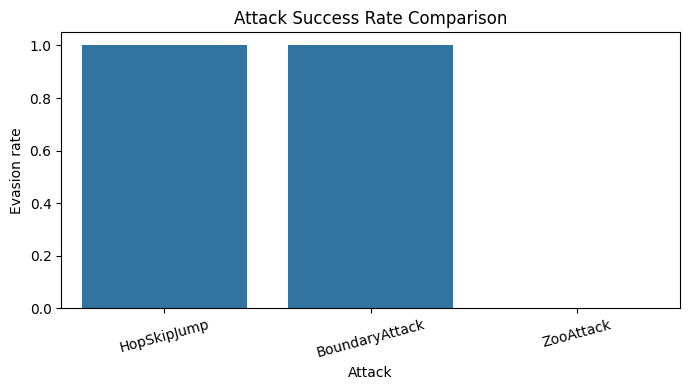

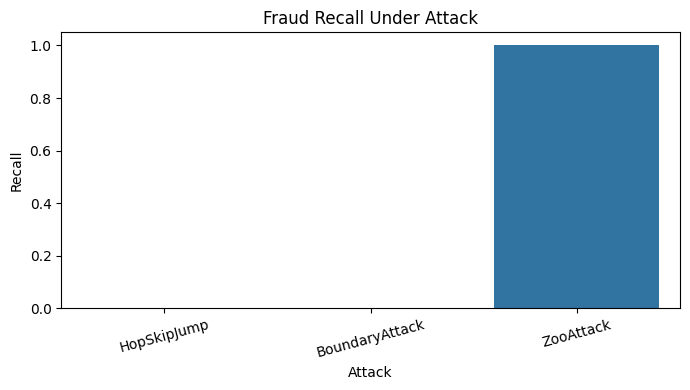

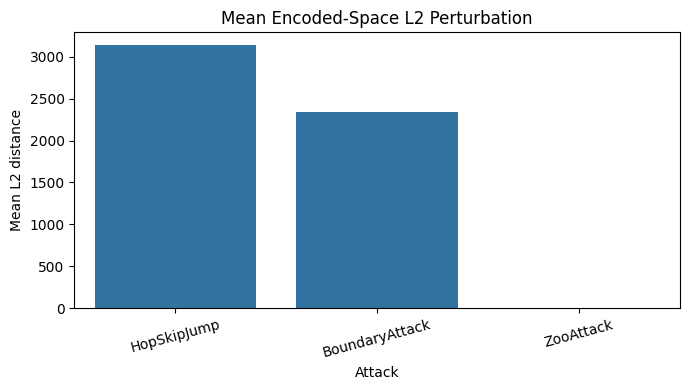

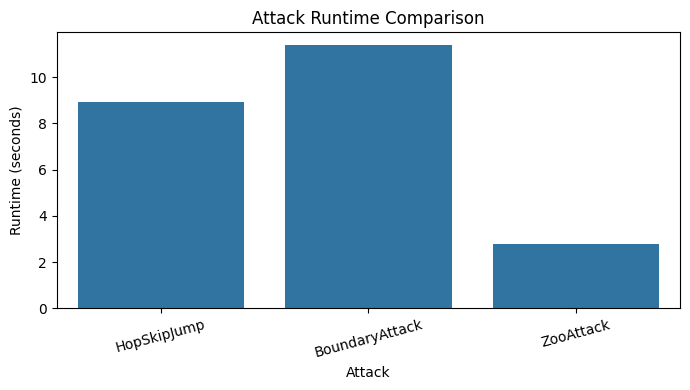

In [30]:
from src.visualization import plot_attack_comparison
PHASE4_FIGURES_DIR = OUTPUT_DIR / 'figures' / 'phase4'
phase4_figures = plot_attack_comparison(phase4_comparison, PHASE4_FIGURES_DIR)
plt.show()

### Cell 37 — Save Phase 4 Outputs

In [31]:
from src.attack_comparison import save_comparison_outputs
phase4_csv_path = METRICS_DIR / 'phase4_attack_comparison.csv'
phase4_json_path = METRICS_DIR / 'phase4_attack_comparison.json'
save_comparison_outputs(
    phase4_comparison, phase4_findings, phase4_attack_compatibility,
    phase4_csv_path, phase4_json_path,
)
print('Saved Phase 4 outputs:', phase4_csv_path, phase4_json_path, sep='\n- ')
for path in sorted(PHASE4_FIGURES_DIR.iterdir()):
    print('-', path)
print('All adversarial samples remain evaluation-only and were not used for training.')

Saved Phase 4 outputs:
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase4_attack_comparison.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase4_attack_comparison.json
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase4/attack_success_rate_comparison.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase4/perturbation_size_comparison.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase4/recall_under_attack_comparison.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase4/runtime_comparison.png
All adversarial samples remain evaluation-only and were not used for training.


# PHASE 5 — Model Hardening

### Cell 38 — Phase 5 Setup

In [32]:
from src import config as project_config
from src.explainability import load_phase1_artifacts, transform_with_saved_preprocessor
from src.data_loader import load_paysim
from src.preprocessing import prepare_features_and_target, resample_training_data
from src.train import stratified_train_test_split

# Load the immutable Phase 1 artifacts; the baseline is comparison-only.
baseline_model, saved_preprocessor, saved_feature_names = load_phase1_artifacts(
    MODELS_DIR / 'baseline_model.joblib',
    MODELS_DIR / 'baseline_preprocessor.joblib',
    MODELS_DIR / 'feature_names.joblib',
)

# Reuse live variables when available, otherwise deterministically reconstruct both splits.
if not all(name in globals() for name in ('X_train', 'X_test', 'y_train', 'y_test')):
    phase5_data = load_paysim(DATASET_PATH, run_mode=RUN_MODE, random_seed=RANDOM_SEED)
    phase5_X_raw, phase5_y = prepare_features_and_target(phase5_data)
    X_train_raw, X_test_raw, y_train, y_test = stratified_train_test_split(
        phase5_X_raw, phase5_y, random_state=RANDOM_SEED
    )
    X_train = transform_with_saved_preprocessor(
        saved_preprocessor, X_train_raw, saved_feature_names
    )
    X_test = transform_with_saved_preprocessor(
        saved_preprocessor, X_test_raw, saved_feature_names
    )
if not all(name in globals() for name in ('X_train_smote', 'y_train_smote')):
    X_train_smote, y_train_smote = resample_training_data(
        X_train, y_train, random_state=RANDOM_SEED,
        sampling_strategy=project_config.SMOTE_SAMPLING_STRATEGY,
    )

HARDENING_TRAIN_ATTACK_SAMPLE_SIZE = getattr(
    project_config, 'HARDENING_TRAIN_ATTACK_SAMPLE_SIZE',
    20 if DEVELOPMENT_MODE else 50,
)
HARDENING_TEST_ATTACK_SAMPLE_SIZE = getattr(
    project_config, 'HARDENING_TEST_ATTACK_SAMPLE_SIZE',
    10 if DEVELOPMENT_MODE else 20,
)
PHASE5_FIGURES_DIR = OUTPUT_DIR / 'figures' / 'phase5'
PHASE5_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
phase5_attack_parameters = {
    'HopSkipJump': {
        'max_iter': project_config.ATTACK_MAX_ITER,
        'max_eval': project_config.ATTACK_MAX_EVAL,
        'init_eval': project_config.ATTACK_INIT_EVAL,
        'init_size': project_config.ATTACK_INIT_SIZE,
    },
    'BoundaryAttack': {
        'max_iter': project_config.BOUNDARY_MAX_ITER,
        'num_trial': project_config.BOUNDARY_NUM_TRIAL,
        'sample_size': project_config.BOUNDARY_SAMPLE_SIZE,
        'init_size': project_config.ATTACK_INIT_SIZE,
    },
    'ZooAttack': {
        'max_iter': project_config.ZOO_MAX_ITER,
        'learning_rate': project_config.ZOO_LEARNING_RATE,
        'nb_parallel': project_config.ZOO_NB_PARALLEL,
    },
}
assert X_train.index.intersection(X_test.index).empty
assert X_train.columns.tolist() == saved_feature_names == X_test.columns.tolist()
print('Phase 5 setup complete. Baseline model remains unchanged.')
print({'train_attack_samples': HARDENING_TRAIN_ATTACK_SAMPLE_SIZE,
       'test_attack_samples': HARDENING_TEST_ATTACK_SAMPLE_SIZE})


Phase 5 setup complete. Baseline model remains unchanged.
{'train_attack_samples': 20, 'test_attack_samples': 10}


### Cell 39 — Select Adversarial TRAIN Source Samples

In [33]:
from src.hardening import select_adversarial_training_sources
X_hardening_source, y_hardening_source, phase5_training_source = select_adversarial_training_sources(
    baseline_model, X_train, y_train,
    sample_size=HARDENING_TRAIN_ATTACK_SAMPLE_SIZE,
    random_state=RANDOM_SEED,
)
assert X_hardening_source.index.intersection(X_test.index).empty
assert y_hardening_source.eq(1).all()
print(json.dumps(phase5_training_source, indent=2))
print('Only original training-split fraud rows were selected.')


{
  "source_split": "training",
  "total_training_fraud": 1600,
  "correctly_detected_training_fraud": 1595,
  "selected_training_fraud": 20,
  "random_seed": 42,
  "phase3_or_phase4_test_samples_reused": false
}
Only original training-split fraud rows were selected.


### Cell 40 — Generate Adversarial TRAIN Examples

In [34]:
from src.attack import generate_constrained_hopskipjump, validate_adversarial_constraints
X_adversarial_train, phase5_train_attack_execution = generate_constrained_hopskipjump(
    baseline_model, X_hardening_source,
    relative_bound=project_config.ATTACK_RELATIVE_BOUND,
    max_iter=project_config.ATTACK_MAX_ITER,
    max_eval=project_config.ATTACK_MAX_EVAL,
    init_eval=project_config.ATTACK_INIT_EVAL,
    init_size=project_config.ATTACK_INIT_SIZE,
    random_state=RANDOM_SEED, verbose=True,
)
validate_adversarial_constraints(
    X_hardening_source, X_adversarial_train,
    relative_bound=project_config.ATTACK_RELATIVE_BOUND,
)
assert X_adversarial_train.index.intersection(X_test.index).empty
print(f'Generated {len(X_adversarial_train)} adversarial TRAIN examples.')
print('No Phase 3/4 adversarial test artifact was loaded or reused.')


HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

...

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

Generated 20 adversarial TRAIN examples.
No Phase 3/4 adversarial test artifact was loaded or reused.


### Cell 41 — Build Augmented Training Set

In [35]:
from src.hardening import build_augmented_training_set
X_hardened_train, y_hardened_train, phase5_augmentation = build_augmented_training_set(
    X_train_smote, y_train_smote, X_adversarial_train,
    source_training_indices=X_hardening_source.index,
    untouched_test_indices=X_test.index,
)
print(json.dumps(phase5_augmentation, indent=2))
print('Every appended adversarial example retains fraud label = 1.')


{
  "clean_training_rows": 44000,
  "adversarial_training_rows": 20,
  "augmented_training_rows": 44020,
  "adversarial_label": 1,
  "test_rows_used_for_training": 0
}
Every appended adversarial example retains fraud label = 1.


### Cell 42 — Train Hardened Model

In [36]:
from src.hardening import train_hardened_model
hardened_model = train_hardened_model(
    X_hardened_train, y_hardened_train, random_state=RANDOM_SEED
)
assert hardened_model is not baseline_model
print('New hardened_model trained with the baseline XGBoost configuration.')
print('baseline_model was not overwritten or refitted.')


New hardened_model trained with the baseline XGBoost configuration.
baseline_model was not overwritten or refitted.


### Cell 43 — Evaluate Hardened Model on Clean Test Set

In [37]:
from src.evaluate import evaluate_binary_classifier
hardened_evaluation = evaluate_binary_classifier(hardened_model, X_test, y_test)
baseline_evaluation_phase5 = evaluate_binary_classifier(baseline_model, X_test, y_test)
clean_comparison = pd.DataFrame([
    {'Model': 'Baseline', **baseline_evaluation_phase5['metrics']},
    {'Model': 'Hardened', **hardened_evaluation['metrics']},
])
display(clean_comparison)
print('Hardened confusion matrix:', hardened_evaluation['confusion_matrix'])
print('The untouched test set was evaluated only; it was never augmented or fitted.')


,Model,precision,recall,f1_score,pr_auc,accuracy_supplementary
0,Baseline,0.9925,0.9925,0.9925,0.996960,0.999423
1,Hardened,0.9925,0.9925,0.9925,0.997208,0.999423


Hardened confusion matrix: [[9997, 3], [3, 397]]
The untouched test set was evaluated only; it was never augmented or fitted.


### Cell 44 — Run Fresh Attacks Against Hardened Model

In [38]:
from src.hardening import select_common_correct_test_fraud
from src.attack_comparison import run_comparison_attack

X_phase5_attack, phase5_test_population = select_common_correct_test_fraud(
    baseline_model, hardened_model, X_test, y_test,
    sample_size=HARDENING_TEST_ATTACK_SAMPLE_SIZE,
    random_state=RANDOM_SEED,
)
phase5_baseline_attacks = {}
phase5_hardened_attacks = {}
phase5_attack_samples = {'Baseline': {}, 'Hardened': {}}
for attack_name, parameters in phase5_attack_parameters.items():
    _, phase5_baseline_attacks[attack_name], phase5_attack_samples['Baseline'][attack_name] = run_comparison_attack(
        attack_name, baseline_model, X_phase5_attack,
        full_test_clean_fraud_recall=phase5_test_population['baseline_clean_fraud_recall'],
        parameters=parameters, relative_bound=project_config.ATTACK_RELATIVE_BOUND,
        random_state=RANDOM_SEED, verbose=True,
    )
    _, phase5_hardened_attacks[attack_name], phase5_attack_samples['Hardened'][attack_name] = run_comparison_attack(
        attack_name, hardened_model, X_phase5_attack,
        full_test_clean_fraud_recall=phase5_test_population['hardened_clean_fraud_recall'],
        parameters=parameters, relative_bound=project_config.ATTACK_RELATIVE_BOUND,
        random_state=RANDOM_SEED, verbose=True,
    )
print(json.dumps(phase5_test_population, indent=2))
print('Fresh attacks were generated independently against both models on the same test rows.')


HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]

...

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "source_split": "untouched_test",
  "total_test_fraud": 400,
  "baseline_clean_fraud_recall": 0.9925,
  "hardened_clean_fraud_recall": 0.9925,
  "common_correctly_detected_test_fraud": 397,
  "selected_test_fraud": 10,
  "used_for_training": false,
  "random_seed": 42
}
Fresh attacks were generated independently against both models on the same test rows.


### Cell 45 — Compare Baseline vs Hardened Robustness

,Attack,Baseline Clean Recall,Baseline Recall Under Attack,Baseline Recall Drop,Baseline Attack Success Rate,Hardened Clean Recall,Hardened Recall Under Attack,Hardened Recall Drop,Hardened Attack Success Rate,Recall Recovery,Reduction in Attack Success Rate,Clean Recall Change,Clean Precision Change,Clean F1 Change,Clean PR-AUC Change
0,HopSkipJump,0.9925,0.0,1.0,1.0,0.9925,0.1,0.9,0.9,0.1,0.1,0.0,0.0,0.0,0.000248
1,BoundaryAttack,0.9925,0.0,1.0,1.0,0.9925,0.1,0.9,0.9,0.1,0.1,0.0,0.0,0.0,0.000248
2,ZooAttack,0.9925,1.0,0.0,0.0,0.9925,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000248


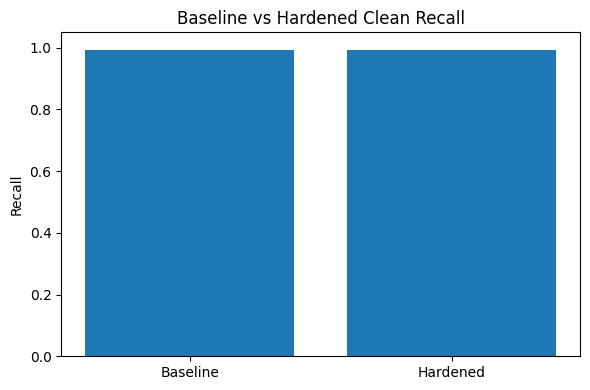

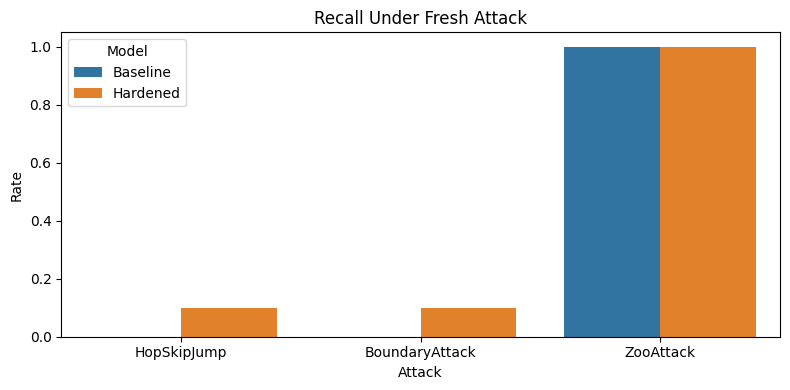

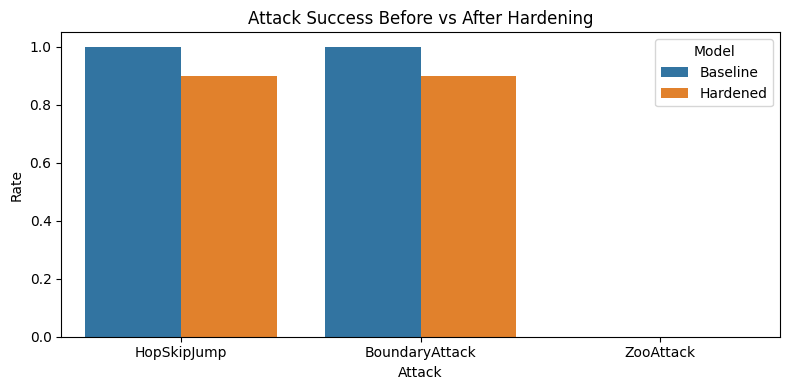

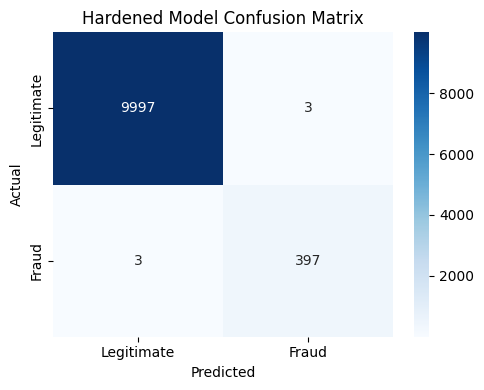

Positive Recall Recovery and positive Reduction in Attack Success Rate indicate improvement.
Actual results may show improvement, no change, or regression; no values are hard-coded.


In [39]:
from src.hardening import build_hardening_comparison
from src.visualization import plot_hardening_comparison
phase5_comparison = build_hardening_comparison(
    baseline_evaluation_phase5['metrics'], hardened_evaluation['metrics'],
    phase5_baseline_attacks, phase5_hardened_attacks,
)
display(phase5_comparison)
phase5_figures = plot_hardening_comparison(
    phase5_comparison, hardened_evaluation['confusion_matrix'], PHASE5_FIGURES_DIR
)
plt.show()
print('Positive Recall Recovery and positive Reduction in Attack Success Rate indicate improvement.')
print('Actual results may show improvement, no change, or regression; no values are hard-coded.')


### Cell 46 — Save Phase 5 Outputs

In [40]:
from src.hardening import save_phase5_outputs
hardened_model_path = MODELS_DIR / 'hardened_model.joblib'
phase5_metrics_path = METRICS_DIR / 'phase5_hardened_metrics.json'
phase5_comparison_path = METRICS_DIR / 'phase5_hardening_comparison.csv'
phase5_methodology = {
    'training_source': phase5_training_source,
    'augmentation': phase5_augmentation,
    'training_attack_execution': phase5_train_attack_execution,
    'fresh_test_attack_population': phase5_test_population,
    'fresh_attacks': list(phase5_attack_parameters),
    'phase3_or_phase4_adversarial_test_samples_used_for_training': False,
    'baseline_model_overwritten': False,
}
save_phase5_outputs(
    hardened_model, hardened_evaluation, phase5_comparison, phase5_methodology,
    hardened_model_path, phase5_metrics_path, phase5_comparison_path,
)
print('Saved Phase 5 outputs:', hardened_model_path, phase5_metrics_path,
      phase5_comparison_path, sep='\n- ')
for output_path in sorted(PHASE5_FIGURES_DIR.iterdir()):
    print('-', output_path)
print('Phase 5 complete. Continue to the Streamlit dashboard sections below.')


Saved Phase 5 outputs:
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/models/hardened_model.joblib
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase5_hardened_metrics.json
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/metrics/phase5_hardening_comparison.csv
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase5/attack_success_comparison.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase5/clean_recall_comparison.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase5/hardened_confusion_matrix.png
- /content/drive/MyDrive/AI_Fraud_Adversarial/outputs/figures/phase5/recall_under_attack_comparison.png
Phase 5 complete. Continue to the Streamlit dashboard sections below.


# PHASE 6 — Streamlit Dashboard
Implemented in `app.py` and `src/dashboard_utils.py`. The dashboard reads the saved Phase 1–5 artifacts without retraining.

Colab launch commands:

```python
%env PAYSIM_DATASET_PATH=/content/drive/MyDrive/AI_Fraud_Adversarial/data/paysim.csv
%env OUTPUT_DIR=/content/drive/MyDrive/AI_Fraud_Adversarial/outputs
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &
from google.colab import output
output.serve_kernel_port_as_window(8501)
```

# PHASE 7 — Real-Time Transaction Simulation
Implemented as the **Real-Time Simulation** dashboard section using `src/realtime_simulation.py`.

It streams a small reproducible, class-aware PaySim sample through the saved preprocessor and hardened model. `isFraud` is used only for evaluation/display. This is a synthetic simulation, not a live banking feed.

Use the Phase 6 launch commands above, then select **Real-Time Simulation** in the Streamlit sidebar.

# PHASE 8 — Concept Drift
Implemented as the **Concept Drift** section in the Streamlit dashboard using `src/concept_drift.py`.

The unchanged hardened model is evaluated over fixed, equal-width PaySim `step` ranges. Feature drift uses bounded deterministic samples and the two-sample Kolmogorov–Smirnov statistic. `isFraud` is retained only for metrics.

Launch the dashboard with the Phase 6 commands above, select **Concept Drift**, and run the analysis. This is simulated PaySim temporal analysis, not evidence of production drift.

# FINAL — Results and Conclusions

The implementation workflow is complete. Use only the metrics and figures produced by this execution when writing conclusions; no result is hard-coded in the notebook.

Collect the following from Google Drive for the final report:

- Phase 1 baseline Precision, Recall, F1, PR-AUC, confusion matrix, and PR curve
- Phase 2 global SHAP ranking, beeswarm, and two local waterfall explanations
- Phase 3 constrained evasion metrics and perturbation figures
- Phase 4 attack-comparison CSV/JSON and four comparison figures
- Phase 5 clean and adversarial baseline-versus-hardened results
- Phase 7 simulation export when a dashboard simulation is run
- Phase 8 chronological drift CSV/JSON and five drift figures

All adversarial test samples remain evaluation-only, and the Streamlit dashboard does not retrain models.